<h1>Python Group Project&nbsp;
<img src='https://upload.wikimedia.org/wikipedia/commons/4/43/Blue_circle_for_diabetes.svg' width='20' height='20'>
&nbsp;Diabetes Data Analysis&nbsp;</h1>
Blanka Hodur, Marcella King, Tim Barker
<br>UC Davis Python for Data Analysis (243PYT303 2024/25 Winter)
<br>Instructor: Alayna C. Myrick
<!--
0     Title
1     Introduction and Overview
1.1   Dataset Background
1.2   Dataset Variables
1.2.1 Diabetes Pedigree Function (DPF)
1.2.2 Outcome
1.3   Diabetes Background
1.3.1 Glucose: The Key Predictor of Diabetes
1.4   Hypothesis
2     Data Import and Inspection
2.1   Import Packages
2.2   Import Dataset
3     Data Cleaning and Validation
3.1   Zero Values in Pregnancies
3.2   Default Values in DPF
3.3   Imputing Missing Data
4     Exploratory Data Analysis (EDA)
4.1   Data Overview
4.2   Age Grouping and Distribution
4.3   Descriptive Statistics by Outcome
5     Data Vizualization
5.1   Univariate and Bivariate Exploration
5.1.1 Histrograms
5.1.2 Correlation Matrix
5.1.3 Pairplot
5.2   Multivariate Exploration and Relationships
5.2.1 Boxplots
5.2.2 Barchart
5.2.3 Glucose vs. Age
5.2.4 Kernel Density Estimate (KDE)
5.2.5 Scatterplot Matrix (SPLOM)
5.2.6 Parallel Plot
5.3   Exploration Summary
6     Data Modeling
6.1   Model 1: Glucose vs. Outcome
6.1.1 Interpreting Model 1b
6.1.2 Visualizing Model 1b
6.2   Model 2: Glucose + Insulin vs. Outcome
6.2.1 Interpreting Models 2a and 2b
6.2.2 Visualizing Model 2b
6.3   Training and Testing Model 1b
6.3.1 Interpreting Model 1b Accuracy
7     Results
7.1   Model Analysis
7.1.1 Models 1a & 1b: Glucose vs. Outcome
7.1.2 Models 2a & 2b: Glucose + Insulin vs. Outcome
7.2   Observations and Interpretation
7.3   Further Considerations
7.4   Conclusion
8     Summary and Recommendations
8.1   Recommendations
9     Sources
-->

<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Introduction and Overview</h2>

This project utilized the _Pima Indian Diabetes Dataset_ to explore the role of glucose as a predictor of diabetes. The analysis encompasses data cleaning, visualization, and the application of logistic regression to model the relationship between glucose and having diabetes. The goal was to gain proficiency in data analysis techniques while investigating a relevant health-related dataset.

### Dataset Background

The _Pima Indian Diabetes Dataset_ (PIDD) is commonly used for training machine-learning models to predict the likelihood of diabetes development within five years. It is derived from a cohort of Native-American women from the Gila River Indian Community in Arizona during the 1980s. The population was studied by the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) due to having one of the highest incidence rates of type 2 diabetes (T2D) in the world.<sup>[[1](#source1)]</sup>  

This dataset is widely referenced in healthcare and machine learning research, providing a valuable benchmark for testing prediction models. It includes key features such as age, BMI, glucose levels, and family history—factors that contribute significantly to the onset of diabetes.<sup>[[2](#source2)]</sup>

### Dataset Variables

The dataset includes the following variables<sup>[[3](#source3)]</sup>:

0. `Pregnancies`: Number of pregnancies
1. `Glucose`: Plasma glucose concentration at 2 hours in an oral glucose tolerance test (mg/dl)
2. `BloodPressure`: Diastolic blood pressure (mm Hg)
3. `SkinThickness`: Triceps skinfold thickness (mm)
4. `Insulin`: 2-hour serum insulin (&micro;U/ml)
5. `BMI`: Body mass index (weight in kg / (height in m)<sup>2</sup>)
6. `DiabetesPedigreeFunction` (DPF): Family history-based risk score
7. `Age`: Age (years) at the time of the exam
8. `Outcome`: Class variable (0 for non-diabetic, 1 for diabetic)

#### Diabetes Pedigree Function (DPF)

The `DiabetesPedigreeFunction` (DPF) is a family history-based risk score estimating an individual’s genetic predisposition to diabetes. It considers the ages at which relatives were diagnosed with diabetes and their last non-diabetic checkup, weighted by genetic closeness. Higher scores indicate greater genetic risk.

The formula for DPF is as follows<sup>\[[4](#source4)]</sup>:
##### $DPF=\Large\frac{\sum_{i}K_{i}(88-ADM_{i})+20}{\sum_{j}K_{j}(ALC_{j}-14)+50}$
Where:
- *i* and *j* represent relatives diagnosed with diabetes or not.
- *K<sub>x</sub>* represents genetic closeness (e.g., 0.5 for a parent, 0.25 for a half-sibling).
- *ADM<sub>i</sub>* and *ALC<sub>j</sub>* are the ages at which these relatives were diagnosed or last checked for diabetes.
- Constants adjust for extreme ages or missing data.




#### Outcome

The `Outcome` variable indicates whether the individual developed diabetes within 1-5 years, based on a 2-hour oral glucose tolerance test (GTT) with a threshold &ge; 200 mg/dl.<sup>\[[5](#source5)]</sup>

### Diabetes Background

Diabetes is a chronic condition affecting how the body regulates blood sugar (glucose).<sup>\[[6](#source6)]</sup> The two main types of diabetes are:
- **Type 1 Diabetes (T1D)**: The body does not produce insulin, a hormone that helps cells absorb glucose.
- **Type 2 Diabetes (T2D)**: The body either becomes resistant to insulin or doesn't produce enough of it, leading to elevated blood sugar levels.

Insulin acts like a key, letting glucose enter cells for energy. Chronic high blood glucose levels forces the body to produce excess insulin, making cells less responsive—like a worn-out lock. As glucose builds up in the blood, insulin resistance worsens, leading to fat storage, inflammation, and pancreatic damage. This cycle increases the risk of type 2 diabetes. If untreated, uncontrolled diabetes can lead to complications like heart disease, kidney damage, nerve damage, and vision problems. Exercise and a healthy diet can help restore insulin sensitivity.

<div><img src='images/diabetes.png' width='533' height='300' /></div>

#### Glucose: The Key Predictor of Diabetes

Glucose levels are one of the strongest predictors of type 2 diabetes due to their direct correlation with insulin resistance. Elevated glucose during an oral glucose tolerance test (GTT) often signals the onset of insulin resistance, a precursor to full diabetes. This makes glucose a key indicator for early diagnosis.<sup>\[[7](#source7)]</sup>

### Hypothesis:
We hypothesize that higher `Glucose` levels significantly increase the likelihood of developing type 2 diabetes within a five-year period, with glucose levels acting as a key driver in the onset of diabetes `Outcome`.

<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Data Import and Inspection</h2>

### Import Packages

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.express import parallel_categories

# Statistical modeling
from statsmodels.formula.api import logit
from sklearn.linear_model import LogisticRegression
from patsy import dmatrices

# Machine learning
import sklearn.model_selection as ms
from sklearn.metrics import accuracy_score

### Read Dataset

In [2]:
diabetes = pd.read_csv('https://www.kaggle.com/api/v1/datasets/download/deependraverma13/diabetes-healthcare-comprehensive-dataset?file_name=health%20care%20diabetes.csv')

The first few rows of the dataset are shown below, providing a glimpse into the structure and variables included:

In [3]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


A summary of the dataset's information, including data types and the number of non-null values, is shown below:

In [4]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Descriptive statistics for the numerical features are presented below, including count, mean, standard deviation, and quartiles:

In [5]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Data Cleaning and Validation</h2>

Zero values for variables like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, and `Age` are clinically unrealistic for this dataset and represent missing or erroneous data. These zeros are replaced with *NaN* to indicate missing values.

In [6]:
columns_to_convert = diabetes.columns.difference(['Outcome', 'Pregnancies']) # Create list of columns excluding Outcome and Pregnancies
diabetes[columns_to_convert] = diabetes[columns_to_convert].astype('float64')  # Convert columns to float64
diabetes[columns_to_convert] = diabetes[columns_to_convert].replace(0, np.nan)  # Replace 0s with NaN

The number of missing values _(NaN)_ in each column is shown below:

In [7]:
diabetes.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### Zero Values in Pregnancies
Some variables have zero values, likely representing missing data. However, `Pregnancies` can legitimately be zero, indicating no prior pregnancies. The issue is that we cannot distinguish true zeros from missing values. This infers uncertainty, making Pregnancies a questionably reliable indicator for analysis. Let's examine this variable for any unexpected zero value counts.

In [8]:
count_percent_df = diabetes['Pregnancies'].value_counts().reset_index()  # Get counts of unique values in 'Pregnancies' and reset index
count_percent_df.columns = ['Pregnancies', 'Count']  # Rename the columns to 'Pregnancies' and 'Count'
count_percent_df['Percentage'] = ((count_percent_df['Count'] / count_percent_df['Count'].sum()) * 100).round(2)  # Calculate and round the percentage to 2 decimal places
count_percent_df_sorted = count_percent_df.sort_values(by='Pregnancies').reset_index(drop=True)  # Sort by 'Pregnancies' and reset index

The distribution of the number of pregnancies is shown below:

In [9]:
print(count_percent_df_sorted.to_string(index=False))

 Pregnancies  Count  Percentage
           0    111       14.45
           1    135       17.58
           2    103       13.41
           3     75        9.77
           4     68        8.85
           5     57        7.42
           6     50        6.51
           7     45        5.86
           8     38        4.95
           9     28        3.65
          10     24        3.12
          11     11        1.43
          12      9        1.17
          13     10        1.30
          14      2        0.26
          15      1        0.13
          17      1        0.13


### Default Values in DPF
We renamed the `DiabetesPedigreeFunction` column to `DPF` for simplicity.

In [10]:
diabetes = diabetes.rename(columns={'DiabetesPedigreeFunction': 'DPF'})

When there is **no family history**, the constants *K<sub>i</sub>* and *K<sub>j</sub>* related to family history are zero, simplifying the Diabetes Pedigree Function to:

##### $DPF=\Large\frac{\sum_{i}K_{i}(88-ADM_{i})+20}{\sum_{j}K_{j}(ALC_{j}-14)+50}=\frac{20}{50}=0.4$

Let's check `DPF` to see if there are any unusual counts for 0.4 values.

In [11]:
diabetes['DPF'].mode()

0    0.254
1    0.258
Name: DPF, dtype: float64

In [12]:
diabetes['DPF'].value_counts()

DPF
0.258    6
0.254    6
0.268    5
0.207    5
0.261    5
        ..
1.353    1
0.655    1
0.092    1
0.926    1
0.171    1
Name: count, Length: 517, dtype: int64

### Imputing Missing Data

`SkinThickness` (30% missing) and `Insulin` (50% missing) presents a significant challenge. Imputing such a large proportion risks skewing results and introducing substantial bias. We considered various methods, but the extent of missing data made it difficult to ensure the reliability of any imputation. For example, mean/median imputation would reduce variance, potentially underestimating true impact. Therefore, we chose not to impute these variables in our primary analysis, prioritizing the integrity of observed data. While this limits our exploration of these variables, it allows more reliable conclusions from the more complete data like Glucose.

<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Exploratory Data Analysis (EDA)</h2>

### Data Overview

After successful import and cleansing, we first perform deeper exploration to understand its structure, key characteristics, and potential anomalies. This includes sampling rows, summarizing numerical features, and examining unique values in specific columns.

In [13]:
diabetes.sample(n=10, random_state=1)  

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
285,7,136.0,74.0,26.0,135.0,26.0,0.647,51.0,0
101,1,151.0,60.0,NaN,NaN,26.1,0.179,22.0,0
581,6,109.0,60.0,27.0,NaN,25.0,0.206,27.0,0
352,3,61.0,82.0,28.0,NaN,34.4,0.243,46.0,0
726,1,116.0,78.0,29.0,180.0,36.1,0.496,25.0,0
472,0,119.0,66.0,27.0,NaN,38.8,0.259,22.0,0
233,4,122.0,68.0,NaN,NaN,35.0,0.394,29.0,0
385,1,119.0,54.0,13.0,50.0,22.3,0.205,24.0,0
556,1,97.0,70.0,40.0,NaN,38.1,0.218,30.0,0
59,0,105.0,64.0,41.0,142.0,41.5,0.173,22.0,0


We examine summary statistics for `Glucose` levels using .describe(), which provides key insights such as mean, median, and range:

In [14]:
diabetes['Glucose'].describe()

count    763.000000
mean     121.686763
std       30.535641
min       44.000000
25%       99.000000
50%      117.000000
75%      141.000000
max      199.000000
Name: Glucose, dtype: float64

We confirm the max Glucose value is 199, which is consistent with those already diagnosed with diabetes being excluded from the dataset. 

Next, we check unique values in `BloodPressure`, which helps in identifying possible outliers or inconsistencies in health indicators:

In [15]:
diabetes['BloodPressure'].unique()

array([ 72.,  66.,  64.,  40.,  74.,  50.,  nan,  70.,  96.,  92.,  80.,
        60.,  84.,  30.,  88.,  90.,  94.,  76.,  82.,  75.,  58.,  78.,
        68., 110.,  56.,  62.,  85.,  86.,  48.,  44.,  65., 108.,  55.,
       122.,  54.,  52.,  98., 104.,  95.,  46., 102., 100.,  61.,  24.,
        38., 106., 114.])

### Age Grouping and Distribution

To better understand age distribution, we categorize individuals into distinct age groups and calculate their frequency within the dataset. This helps us analyze age-related trends and their relationship with diabetes.

In [16]:
# Create a copy of the DataFrame to avoid modifying the original
diabetes_copy = diabetes.copy()

# Define age group conditions and labels
age_group_conditions = [
    (diabetes_copy['Age'] >= 21) & (diabetes_copy['Age'] < 25),
    (diabetes_copy['Age'] >= 25) & (diabetes_copy['Age'] < 31),
    (diabetes_copy['Age'] >= 31) & (diabetes_copy['Age'] < 41),
    (diabetes_copy['Age'] >= 41) & (diabetes_copy['Age'] < 56),
    (diabetes_copy['Age'] >= 56)
]
age_group_values = ['21-24', '25-30', '31-40', '41-55', '>55']

# Create new column in the copied DataFrame
diabetes_copy['Age Group'] = np.select(age_group_conditions, age_group_values, default='Unknown')

# Compute age group distribution
age_group_counts = diabetes_copy.groupby('Age Group').size().to_frame('Count')
age_group_counts['Percent of Obs'] = (age_group_counts['Count'] / age_group_counts['Count'].sum()) * 100
age_group_counts['Percent of Obs'] = age_group_counts['Percent of Obs'].apply(lambda x: f'{x:.1f}%') # Apply inline format using a lambda

# Display results
age_group_counts

,Count,Percent of Obs
Age Group,,
21-24,219,28.5%
25-30,198,25.8%
31-40,157,20.4%
41-55,144,18.8%
>55,50,6.5%


### Descriptive Statistics by Outcome
Since we know `Outcome` is a target variable of interest, we want to explore aggregate measures grouped by the target variable. The intent is to look for any anomalies that might guide us for further analysis. To do this, we generate two copies of the DataFrame. diabetics: Outcome == 1 and nondiabetics: Outcome == 0.

In [17]:
## Create new dataframe containing data for individuals with diabetes (outcome = 1)
diabetics = diabetes[diabetes['Outcome'] == 1]

Summary statistics for individuals with diabetes (Outcome = 1) are presented below:

In [18]:
## Determine mean of various columns of interest
diabetics.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
count,268.000000,266.000000,252.000000,180.000000,130.000000,266.000000,268.000000,268.000000,268.0
mean,4.865672,142.319549,75.321429,33.000000,206.846154,35.406767,0.550500,37.067164,1.0
std,3.741239,29.599199,12.299866,10.327595,132.699898,6.614982,0.372354,10.968254,0.0
min,0.000000,78.000000,30.000000,7.000000,14.000000,22.900000,0.088000,21.000000,1.0
25%,1.750000,119.000000,68.000000,27.000000,127.500000,30.900000,0.262500,28.000000,1.0
50%,4.000000,140.000000,74.500000,32.000000,169.500000,34.300000,0.449000,36.000000,1.0
75%,8.000000,167.000000,84.000000,39.000000,239.250000,38.925000,0.728000,44.000000,1.0
max,17.000000,199.000000,114.000000,99.000000,846.000000,67.100000,2.420000,70.000000,1.0


In [19]:
## Create new dataframe containing data for individuals with diabetes (outcome = 0)
nondiabetics = diabetes[diabetes['Outcome'] == 0]

Summary statistics for individuals without diabetes (Outcome = 0) are presented below:

In [20]:
## Determine mean of various columns of interest
nondiabetics.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
count,500.000000,497.000000,481.000000,361.000000,264.000000,491.000000,500.000000,500.000000,500.0
mean,3.298000,110.643863,70.877339,27.235457,130.287879,30.859674,0.429734,31.190000,0.0
std,3.017185,24.776906,12.161223,10.026491,102.482237,6.560737,0.299085,11.667655,0.0
min,0.000000,44.000000,24.000000,7.000000,15.000000,18.200000,0.078000,21.000000,0.0
25%,1.000000,93.000000,62.000000,19.000000,66.000000,25.600000,0.229750,23.000000,0.0
50%,2.000000,107.000000,70.000000,27.000000,102.500000,30.100000,0.336000,27.000000,0.0
75%,5.000000,125.000000,78.000000,33.000000,161.250000,35.300000,0.561750,37.000000,0.0
max,13.000000,197.000000,122.000000,60.000000,744.000000,57.300000,2.329000,81.000000,0.0


<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Data Visualizations</h2>

To understand the dataset, we continue our exploration with a series of visualizations to uncover important patterns and relationships between the features. These plots provide an immersive insight into the data and help us identify key areas to investigate further:

- **Histograms**: Shows the distribution of each feature, helping identify skewness, potential outliers, and data spread.
- **Correlation Matrix**: Visualizes relationships between numerical features, highlighting strong correlations that may inform model development.
- **Pairplot**: Displays pairwise relationships between features, helping to uncover potential patterns or clusters in the data, with outcomes categorized by diabetes status.
- **Boxplots**: Identify outliers in each feature, providing insight into potential data quality issues that may need addressing.
- **Countplot**: Displays the distribution of the outcome (diabetes), helping to assess class imbalance and understand the prevalence of diabetes in the dataset.

These initial visualizations set the stage for deeper analysis, allowing us to focus on specific aspects of the dataset that stood out. 

### Univariate and Bivariate Exploration

This section focuses on visualizing the distribution of individual variables (histograms, boxplots) and exploring relationships between pairs of variables (scatter plots, correlation matrices), providing initial insights into the data's characteristics and potential associations.

#### Histograms
To understand the distribution of key variables, we first examined histograms for each feature. The histograms reveal an unusually higher spike in zero `Pregnancies`, which warrants further exploration. The plots also shows a blunt right tail for `Glucose` (expected). This shows a large number of women who are close to diabetes. Note: those with readings 200 or greater are excluded from the dataset since they are already diabetic.

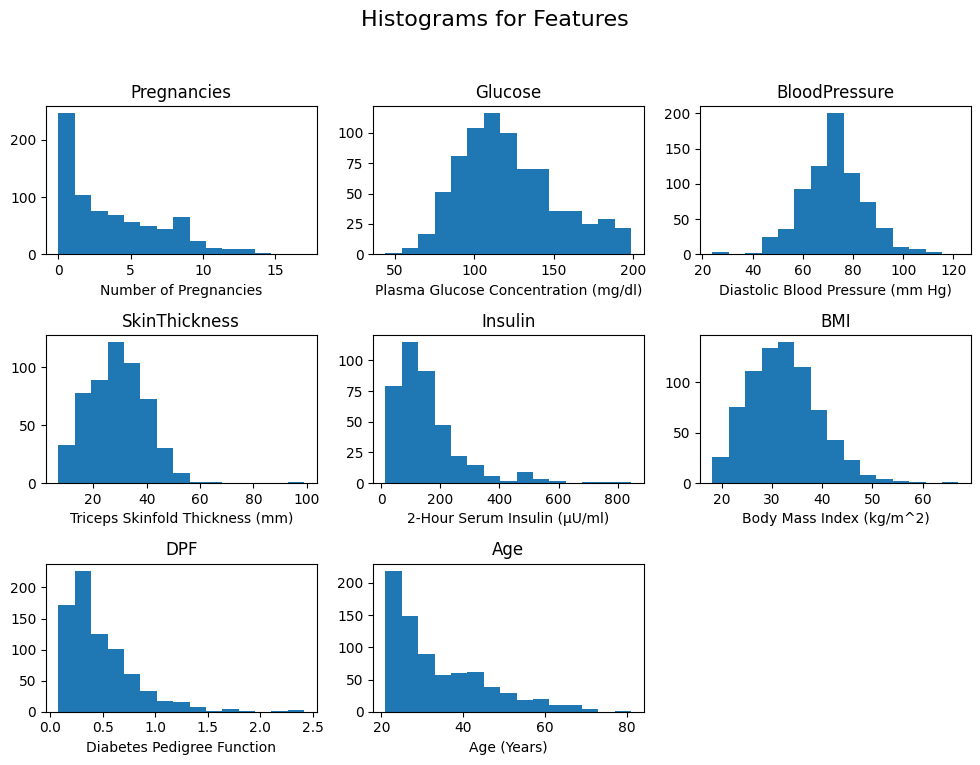

In [21]:
diabetes.drop(columns='Outcome').hist(bins=15, figsize=(10, 8), grid=False)

# x-axis labels
plt.subplot(3, 3, 1)  # Accessing nrows, ncols, index
plt.xlabel('Number of Pregnancies')
plt.subplot(3, 3, 2)
plt.xlabel('Plasma Glucose Concentration (mg/dl)')
plt.subplot(3, 3, 3)
plt.xlabel('Diastolic Blood Pressure (mm Hg)')
plt.subplot(3, 3, 4)
plt.xlabel('Triceps Skinfold Thickness (mm)')
plt.subplot(3, 3, 5)
plt.xlabel('2-Hour Serum Insulin (µU/ml)')
plt.subplot(3, 3, 6)
plt.xlabel('Body Mass Index (kg/m^2)')
plt.subplot(3, 3, 7)
plt.xlabel('Diabetes Pedigree Function')
plt.subplot(3, 3, 8)
plt.xlabel('Age (Years)')

plt.suptitle('Histograms for Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

**Figure 1:** Histograms of Features. This figure displays the distribution of each variable in the dataset, revealing potential skewness and outliers. Note: missing data (zero values in several features) were converted to _NaN_.

#### Boxplots

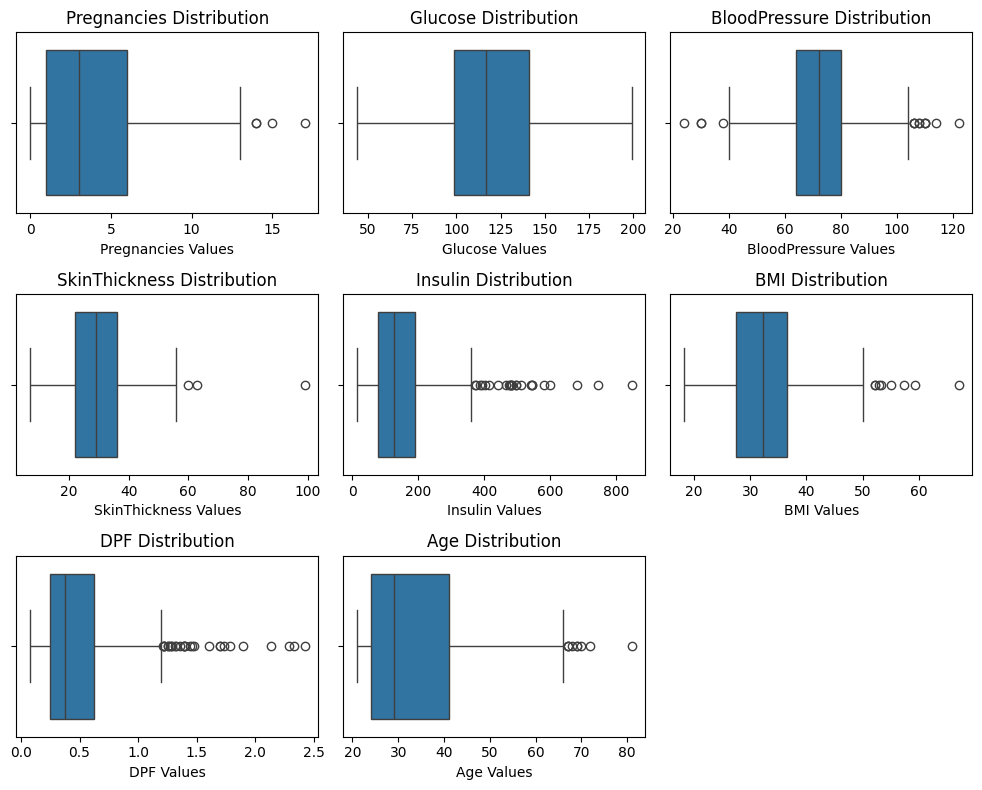

In [22]:
plt.figure(figsize=(10, 8))
for i, column in enumerate(diabetes.drop(columns='Outcome').columns):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=diabetes[column])
    plt.title(f'{column} Distribution')
    plt.xlabel(f'{column} Values')
    
plt.tight_layout()
plt.show()

**Figure 2:** Boxplots of Features. These boxplots illustrate the distribution of each feature, highlighting potential outliers and differences in interquartile ranges.

#### Barchart

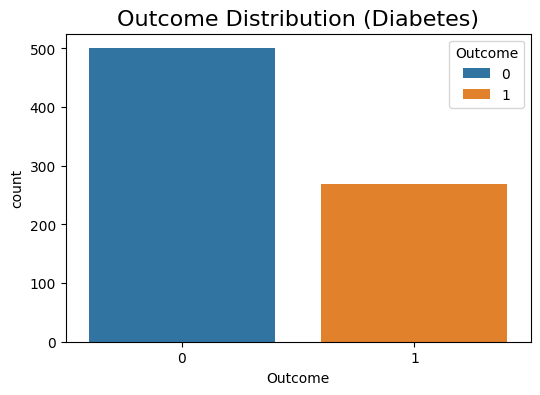

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=diabetes, hue='Outcome')
plt.title('Outcome Distribution (Diabetes)', fontsize=16)
plt.show()

**Figure 3:** Outcome Distribution. This countplot shows the distribution of the target variable, Outcome, indicating the number of individuals with and without diabetes.

### Multivariate Exploration and Relationships

This section delves into the relationships between multiple variables simultaneously, using techniques like SPLOM and parallel plots to uncover complex interactions and dependencies that might not be apparent in bivariate analysis.

#### Correlation Matrix

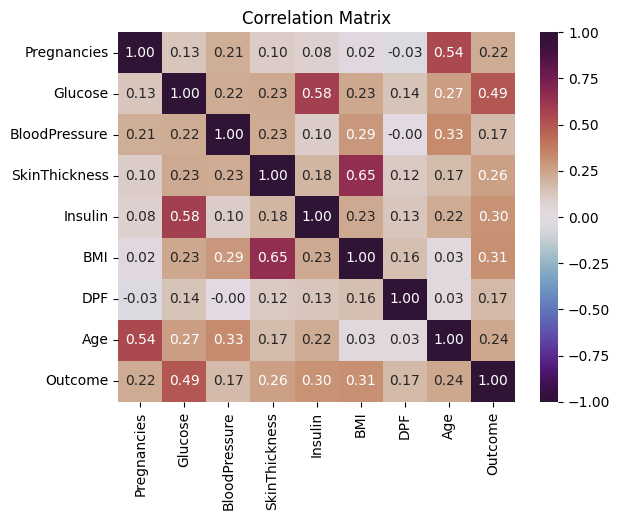

In [24]:
sns.heatmap(diabetes.corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='twilight_shifted')
plt.title('Correlation Matrix')
plt.show()

**Figure 4:** Correlation Matrix. This heatmap visualizes the correlation coefficients between all numerical features. It helps identify potential multicollinearity and highlights strong positive or negative relationships between variables.

This chart points is to Insulin as a potential independent variable of interest alongside our hypothesised variable (Glucose).

#### Pairplot

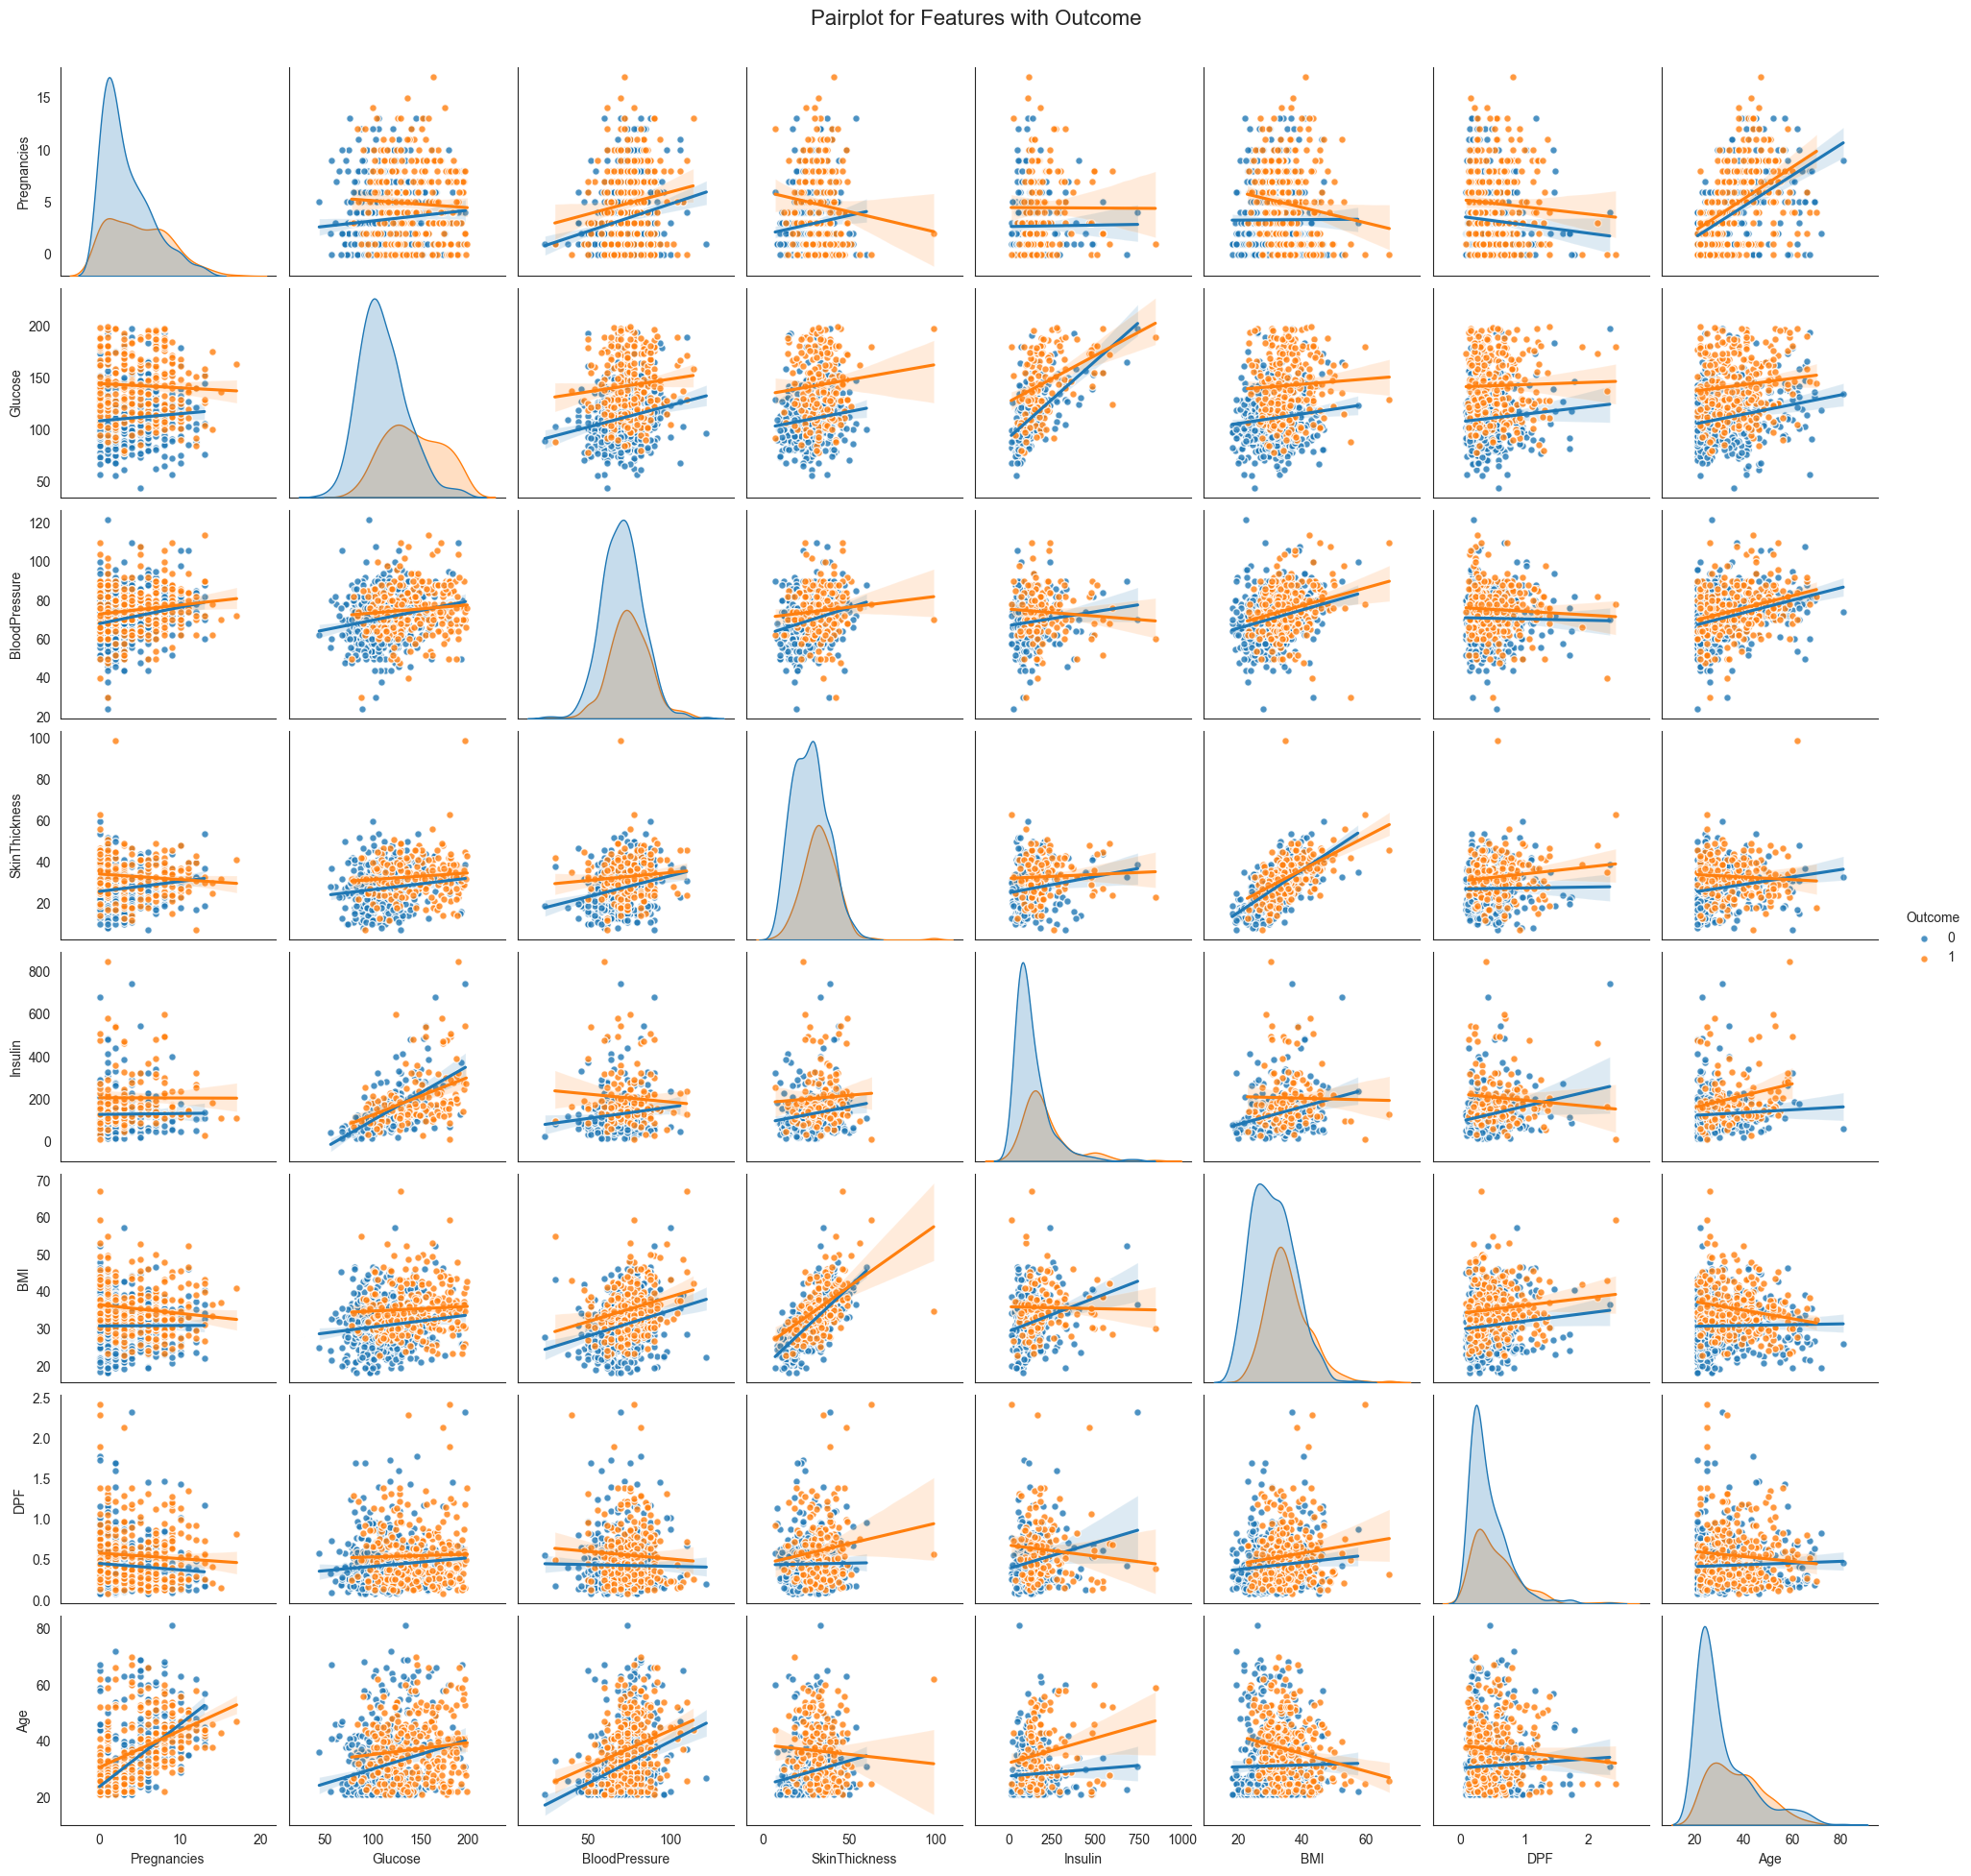

In [25]:
sns.set_style('white')
sns.pairplot(diabetes, hue='Outcome', diag_kind='kde', kind='reg', plot_kws={'scatter_kws': {'s': 30, 'alpha': 0.8, 'edgecolor': 'white'}})
plt.suptitle('Pairplot for Features with Outcome', fontsize=16)
plt.subplots_adjust(top=0.95)
plt.show()

**Figure 5:** Pairplot of Features with Outcome. This scatterplot matrix shows pairwise relationships between all features, with points colored by diabetes outcome (0 = No Diabetes, 1 = Diabetes). It allows for the exploration of potential patterns and clusters within the data.

This chart reveals a striking contrast in Outcome along the Glucose variable, and warrants further exloration.

#### Glucose vs. Age

To further investigate `Glucose` impact, we analyzed its relationship with `Age`. Since diabetes risk increases with age due to metabolic changes, we examined whether older individuals exhibit higher glucose levels.

The scatterplot reveals a trend of higher glucose levels in older individuals, with many falling close the diabetic category. This suggests that age may amplify glucose dysregulation, emphasizing the importance of early detection. Additionally, younger individuals with high glucose levels could indicate early-stage diabetes risk, highlighting the need for preventive monitoring.


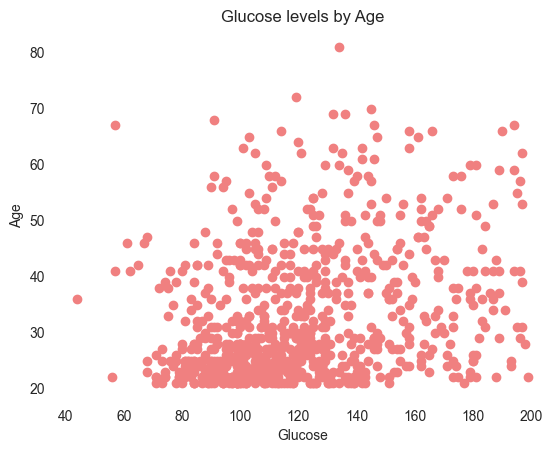

In [26]:
plt.scatter(diabetes['Glucose'], diabetes['Age'], color = 'lightcoral')
plt.title('Glucose levels by Age')
plt.xlabel('Glucose')
plt.ylabel('Age')
plt.box(False)
plt.show()

**Figure 6:** Glucose Levels by Age. This scatterplot examines the relationship between glucose levels and age, revealing a potential trend of increasing glucose with age.

#### Kernel Density Estimate (KDE)

Through the pairplot, we observed that the KDE plot for Glucose by Outcome revealed a strong separation between the distributions of `Glucose` levels for non-diabetic and diabetic individuals. To investigate this further, we created a dedicated KDE plot for glucose levels, which clearly shows that the distribution of glucose for diabetic individuals is shifted to higher values compared to non-diabetic individuals, who have a concentration of glucose values at lower levels.

This separation emphasized that glucose levels are a key differentiator between diabetic and non-diabetic individuals, suggesting its importance as a predictive feature. The KDE plot allowed us to refine this observation, further solidifying glucose as an essential variable in our analysis.

Given the physiological relationship between Glucose and Insulin and the noted correlation between the two, we extended this analysis to Insulin levels. Insulin plays a crucial role in glucose regulation, and impaired insulin response is a hallmark of diabetes. By visualizing the KDE plot for `Insulin` by diabetes `Outcome`, we aimed to explore whether a similar pattern of separation exists, providing further insights into the role of insulin levels in differentiating between diabetic and non-diabetic individuals.


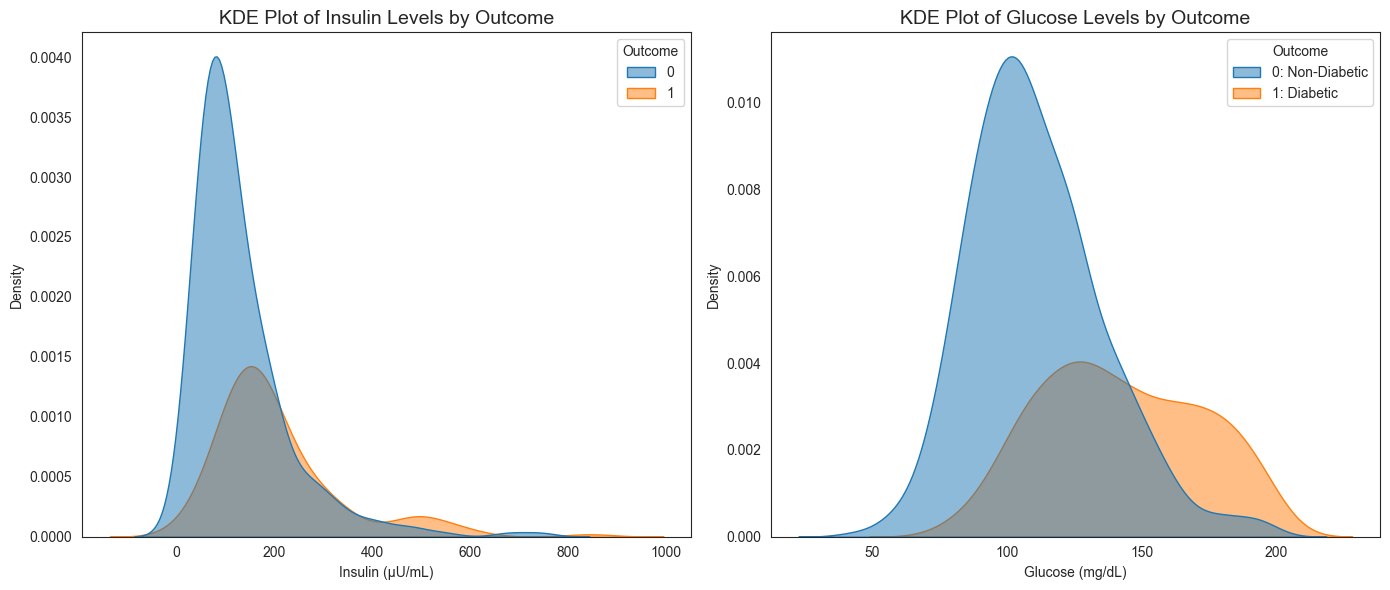

In [27]:
# Create a copy for better labeling
diabetes_kde = diabetes.copy()
diabetes_kde['Outcome'] = diabetes_kde['Outcome'].replace({0: '0: Non-Diabetic', 1: '1: Diabetic'})

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# KDE Plot for Insulin
sns.kdeplot(diabetes, x='Insulin', hue='Outcome', fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title('KDE Plot of Insulin Levels by Outcome', fontsize=14)
axes[0].set_xlabel('Insulin (μU/mL)')

# KDE Plot for Glucose
sns.kdeplot(diabetes_kde, x='Glucose', hue='Outcome', fill=True, alpha=0.5, hue_order=['0: Non-Diabetic', '1: Diabetic'], ax=axes[1])
axes[1].set_title('KDE Plot of Glucose Levels by Outcome', fontsize=14)
axes[1].set_xlabel('Glucose (mg/dL)')

# Adjust layout
plt.tight_layout()
plt.show()

**Figure 7:** Kernel Density Estimation (KDE) Plots of Insulin and Glucose. These plots show the distribution of Insulin and Glucose levels for both diabetic and non-diabetic individuals, highlighting the separation of Glucose distributions between the two groups.

#### Scatterplot Matrix (SPLOM)

Building on the insights from the pairplot and the KDE, we recognized the need to explore how glucose levels interact with other features in the dataset and whether this pattern holds across multiple variables. This led us to choose a Scatterplot Matrix (SPLOM) using an interactive Python library (Plotly), a powerful tool that allows us to explore correlations between several features at once. The SPLOM provides a clearer, more granular view of the relationships between `Glucose` levels and other variables, while maintaining the distinction between non-diabetic and diabetic individuals through color-coded `Outcome` dots.

By adding a vertical line at the median glucose value, we were able to highlight the point at which the glucose distribution appears to visually shifts: individuals with glucose values higher than the median are more likely to be diabetic, as indicated by the red dots. This further reinforced glucose’s role as a key predictor in diabetes, demonstrating its relevance to both exploratory data analysis and future predictive modeling.


In [28]:
filtered_columns = [col for col in diabetes.columns if col != 'Outcome']
outcome_text = ['non-diabetic' if val == 0 else 'diabetic' for val in diabetes['Outcome']]

fig = go.Figure(data=go.Splom(
    dimensions=[dict(label=col, values=diabetes[col]) for col in filtered_columns],
    showupperhalf=False,
    marker=dict(
        color=diabetes['Outcome'],
        size=5,
        colorscale='Bluered',
        opacity=0.5,
        line=dict(width=0.5, color='rgb(230,230,230)')
    ),
    text=outcome_text,
    diagonal=dict(visible=False)
))

fig.update_layout(
    title='Scatterplot Matrix (SPLOM) for Diabetes Dataset',
    width=1000,
    height=1000,
    annotations=[  # Lines along Glucose variable
        dict(  # Vertical line
            x=0.2069,
            y=0, 
            xref='paper',  
            yref='paper',
            text='median',  
            showarrow=True,  
            arrowhead=0,  
            ax=0, 
            ay=-765,  
        ),
        dict(  # Horizontal line
            x=0,  
            y=0.9319,  
            xref='paper',  
            yref='paper',
            text='median',  
            showarrow=True,  
            arrowhead=0,  
            ax=174, 
            ay=0, 
        )
    ]
)

fig.show()

<div><img src='images/splom.png' /></div>

**Figure 8:** Scatterplot Matrix (SPLOM). This interactive plot visualizes the relationships between all variables, with points colored by diabetes outcome. The vertical and horizontal lines mark the median glucose value.

#### Parallel Plot

A parallel plot allows for the exploration of categories by displaying multiple variables as vertical axes. Each data point is represented by a line connecting its values across these axes. In the diabetes dataset, each continuous variable is converted to a discrete variable by binning the values into interquartile ranges; the plot helps compare groupings of variables like Pregnancies, Glucose, BMI while distinguishing outcomes (diabetes vs. no diabetes) using color.

First, we create a function that converts continuous variables into discrete interquartile range (IQR) categories:

In [29]:
def bin_continuous_variables(df):
    '''
    Bins continuous variables in a DataFrame based on statistical percentiles.
    Handles missing values by assigning them to a 'missing' category.

    Parameters:
        df (pandas.DataFrame): The input DataFrame containing numeric columns.

    Returns:
        pandas.DataFrame: A DataFrame with binned columns and a 'missing' category.
    '''
    
    describe_output = df.describe().transpose().round(1)
    binned_columns = {}
    
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        pmin = describe_output.loc[column, 'min']
        p25 = describe_output.loc[column, '25%']
        p50 = describe_output.loc[column, '50%']
        p75 = describe_output.loc[column, '75%']
        pmax = describe_output.loc[column, 'max']
        
        bins = sorted([pmin, p25, p50, p75, pmax])

        # Ensure the last bin is inclusive
        bins[-1] = round(bins[-1] + 0.1, 1) # added 0.1 to include the max value in the last bin
        bins = list(sorted(set(bins)))  # remove duplicates

        labels = [
            f'[{bins[i]}-{bins[i+1]})' if i!= len(bins)-2 else f'[{bins[i]}-{bins[i+1]}]'
            for i in range(len(bins)-1)
        ]
        
        # Create the binned column and assign it to the correct dictionary key
        binned_col = pd.cut(df[column], bins=bins, labels=labels, right=False)

        # Convert to object type and fill NaN values with 'missing'
        binned_columns[f'{column}_Bands'] = binned_col.astype(object).fillna('missing')

    binned_df = df.copy()
    binned_df = binned_df.assign(**binned_columns)

    return binned_df

Next, we use plot the parallel categories using the binned data.

In [30]:
diabetes_Bands = bin_continuous_variables(diabetes)
ribbonFigure = parallel_categories(
    diabetes_Bands, 
    dimensions=['Pregnancies_Bands', 'Glucose_Bands', 'SkinThickness_Bands',
                'Insulin_Bands', 'BMI_Bands', 'DPF_Bands', 'Age_Bands', 'Outcome'],
    color='Outcome',
    width=1100,
)
ribbonFigure.update_layout(
    title='Parallel Categories Plot of Binned Diabetes Variables',
    coloraxis_showscale=False,
)
ribbonFigure.show()

<div>
    <img src='images/parallel.png' />
</div>

**Figure 9:** Parallel Categories Plot. This plot displays the relationships between binned continuous variables and the outcome. It helps to visualize how different combinations of variable ranges relate to diabetes status. The [] and () notation indicates how the binned values are defined. For example, [40-48) is equivalent to the condition 40 <= value < 48, where values of 40 are included but values of 48 are not.

The plot reveals that the observations with missing SkinThickness values are also missing Insulin values. Both have very high counts of missing values.

### Exploration Summary

We began our data exploration with a set of broad visualizations to identify general patterns in the dataset, such as distributions and relationships between features. The KDE plot for `Glucose` helped us identify a clear separation between non-diabetic and diabetic individuals based on glucose levels, which prompted us to investigate further. To dive deeper, we turned to the Scatterplot Matrix (SPLOM), which allowed us to see how glucose interacts with other features and confirmed that glucose is a strong predictor of diabetes. The Correlation Heatmap helped us identify the Insulin variable for further investigation due to its correlation with Glucose.

Through these layered visualizations, we were able to refine our understanding of the dataset, uncovering critical insights about glucose levels and their relationship to diabetes that will be vital for future modeling.

<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Data Modeling</h2>

### Model 1: Glucose vs. Outcome

`Outcome` is a class binary variable (representing the presence or absence of diabetes). Therefore, logistic regression is the most suitable choice for regression modeling because it is designed for such binary classification problems. It also offers a good balance between predictive performance and interpretability. This model is computationally efficient, making it suitable for our initial exploration and baseline model development.

To start, we will model using one independent variable (`Glucose`), however we will run it twice. The first is with _NaN_ values and the second is with imputed values. We want to see if the missing values have a significant influence on the model outputs. We also chose to run regression for `Insulin` alone, just to see how strong of a predictor it might or might not be based on our prior curiosity.

In [31]:
# Extract the predictor variables
X1 = diabetes['Glucose']
X2 = diabetes['Insulin']

# Extract the target variable (Outcome)
y1 = diabetes['Outcome']

# Combine X and y into a list of tuples
zipped_1ab = list(zip(X1, y1))  
zipped_1c = list(zip(X2, y1))  

# Create a DataFrame from the zipped list
df_1a = pd.DataFrame(zipped_1ab, columns=['Glucose', 'Outcome']) 
df_1b = df_1a.copy()  # Create a copy
df_1c = pd.DataFrame(zipped_1c, columns=['Insulin', 'Outcome']) 

median_glucose = df_1b['Glucose'].median() # Calculate the median once
df_1b.loc[:, 'Glucose'] = df_1b.loc[:, 'Glucose'].fillna(median_glucose) # Use.loc

# Use patsy to create design matrices for the logistic regression
y1a, X_1a = dmatrices('Outcome ~ Glucose', df_1a, return_type='dataframe')  
y1b, X_1b = dmatrices('Outcome ~ Glucose', df_1b, return_type='dataframe')  
y1c, X_1c = dmatrices('Outcome ~ Insulin', df_1c, return_type='dataframe')  

# Convert y to a 1-dimensional array
y_1a = np.ravel(y1a)  
y_1b = np.ravel(y1b)  
y_1c = np.ravel(y1c)  

# Fit the logistic regression model (with no intercept)
model1a = LogisticRegression(C=100000, fit_intercept=False)  
model1b = LogisticRegression(C=100000, fit_intercept=False)
model1c = LogisticRegression(C=100000, fit_intercept=False)
model_1a = model1a.fit(X_1a, y_1a)
model_1b = model1b.fit(X_1b, y_1b)
model_1c = model1c.fit(X_1c, y_1c)

The coefficients from the logistic regression model are shown below:

In [32]:
print('Model 1a: Logistic Regression for Outcome (Glucose with NaN)')  
print(pd.DataFrame(np.transpose(model_1a.coef_), X_1a.columns),'\n')
print('Count of NaN values:')
print(df_1a.isnull().sum())
print('-' * 50)

print('Model 1b: Logistic Regression for Outcome (Glucose missing data replaced with median)')  
print(pd.DataFrame(np.transpose(model_1b.coef_), X_1b.columns),'\n')
print('Count of NaN values:')
print(df_1b.isnull().sum())
print('-' * 50)

print('Model 1c: Logistic Regression for Outcome (Insulin)')  
print(pd.DataFrame(np.transpose(model_1c.coef_), X_1c.columns),'\n')
print('Count of NaN values:')
print(df_1c.isnull().sum())

Model 1a: Logistic Regression for Outcome (Glucose with NaN)
                  0
Intercept -5.715076
Glucose    0.040634 

Count of NaN values:
Glucose    5
Outcome    0
dtype: int64
--------------------------------------------------
Model 1b: Logistic Regression for Outcome (Glucose missing data replaced with median)
                  0
Intercept -5.701615
Glucose    0.040565 

Count of NaN values:
Glucose    0
Outcome    0
dtype: int64
--------------------------------------------------
Model 1c: Logistic Regression for Outcome (Insulin)
                  0
Intercept -1.626106
Insulin    0.005701 

Count of NaN values:
Insulin    374
Outcome      0
dtype: int64


Five `Glucose` values (<1% of 768 observations) were missing. We replaced the _NaN_ values with the median. Model 1a contains _NaN_ and Model 1b contains imputed medians. The coefficients changed minimally (intercept: -5.715076 to -5.701615; glucose: 0.040634 to 0.040565), confirming glucose's strong predictive power. While the imputation's impact was small here, handling missing data is crucial. Our median imputation and coefficient stability give reasonable confidence in the glucose-diabetes risk relationship. Our third test in Model 1c shows a coefficent of 0.005701 for `Insulin`.

We discard Models 1a and 1c and keep Model 1b. We build a function to run the regression model since we will be using it again in subsequent analysis.

In [33]:
def logistic_regression_models(df: pd.DataFrame, outcome_var: str, predictor_vars: list[str] | None = None):
    '''Fits and prints logistic regression models.

    If predictor_vars is None, creates one model with all numeric
    variables in the DataFrame. If predictor_vars is provided,
    creates one model with all specified predictors.

    Parameters
    ----------
    df: pd.DataFrame
        The pandas DataFrame containing the data.
    outcome_var: str
        The name of the outcome variable (must be binary).
    predictor_vars: list[str] | None, optional
        A list of predictor variables. If None, uses all
        numeric columns in the DataFrame. The default is None.

    Returns
    -------
    None.
    '''

    if predictor_vars is None:
        # Use all numeric columns in a single model
        predictor_vars = [col for col in df.select_dtypes(include=['number']).columns if col!= outcome_var]
        print(f'Logistic Regression Model: {outcome_var} vs. All Numeric Variables')
    else:
        print(f'Logistic Regression Model: {outcome_var} vs. {', '.join(predictor_vars)}')

    # Common part for both cases:
    formula = f'{outcome_var} ~ {' + '.join(predictor_vars)}'
    model = logit(formula, data=df).fit()
    print(model.summary())
    print('-' * 50)

Now, we obtain the pseudo-R<sup>2</sup> and p values for Model 1b:

In [34]:
logistic_regression_models(df_1b, 'Outcome', ['Glucose'])

Logistic Regression Model: Outcome vs. Glucose
Optimization terminated successfully.
         Current function value: 0.516692
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      766
Method:                           MLE   Df Model:                            1
Date:                Wed, 19 Feb 2025   Pseudo R-squ.:                  0.2012
Time:                        19:50:33   Log-Likelihood:                -396.82
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 2.258e-45
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.7016      0.437    -13.049      0.000      -

#### Interpreting Model 1b

The results of the logistic regression analysis supports our hypothesis that higher Glucose levels increase the likelihood of developing type 2 diabetes within a five-year period.
- **Statistical Significance**: The `Glucose` coefficient is 0.0406 and is statistically significant (p < 0.001). This means there is a very low probability (less than 0.1%) of observing such a strong relationship between Glucose and the `Outcome` (diabetes development) by chance alone.
- **Positive Relationship**: The positive coefficient (0.0406) indicates a positive relationship between Glucose and the likelihood of developing diabetes. As Glucose levels increase, the odds of developing diabetes also increase.
- **Magnitude of Effect**: For a one-unit increase in Glucose, the log-odds of developing diabetes increase by 0.0406. To understand this in terms of layman odds, we take the exponential of the coefficient: _e_<sup>(0.0406)</sup> ≈ 1.042. The odds ratio of 1.042 means that for every 1 mg/dl increase in glucose, the odds of developing diabetes increase by 4.2%.
- **Model Fit**: The pseudo-R<sup>2</sup> value of 0.2012 suggests that the model explains about 20.1% of the variability in the outcome. While not extremely high, this indicates that Glucose is a significant predictor of diabetes development.

#### Visualizing Model 1b

First, we take the log-odds(Outcome) formula:
##### $Ln(\Large\frac{P}{1-P})=\beta_0 + \beta_1 X_1 = -5.701615 + (0.040565 \times Glucose)$ 

Then, plug it into the sigmoid function:

##### $p(Outcome) = \Large\frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1)}} = \frac{1}{1 + e^{-(-5.701615 + (0.040565 \times Glucose))}}$

In [35]:
# 1. Scatter plot of the data points
fig = go.Figure()

# Separate data for each outcome for coloring
outcome_0 = df_1b[df_1b['Outcome'] == 0]
outcome_1 = df_1b[df_1b['Outcome'] == 1]

fig.add_trace(go.Scatter(
    x=outcome_0['Glucose'],
    y=outcome_0['Outcome'],
    mode='markers',
    opacity=0.8,
    marker=dict(
        color='blue',  # Color for Outcome 0 (NOT diabetic)
        size=8,
        opacity=0.5,
        line=dict(width=0.5, color='rgb(230,230,230)')
    ),
    name='Outcome 0'
))

fig.add_trace(go.Scatter(
    x=outcome_1['Glucose'],
    y=outcome_1['Outcome'],
    mode='markers',
    opacity=0.8,
    marker=dict(
        color='red',  # Color for Outcome 1 (diabetic)
        size=8,
        opacity=0.5,
        line=dict(width=0.5, color='rgb(230,230,230)')
    ),
    name='Outcome 1'
))

# 2. Plot the logistic regression curve (using the formula with np.exp)
glucose_range = np.linspace(df_1b['Glucose'].min(), df_1b['Glucose'].max(), 100)

# Calculate probabilities using the inputs
intercept = -5.701615 
coefficient = 0.040565  

# Calculate probabilities using the formula
probabilities = 1 / (1 + np.exp(-(intercept + (coefficient * glucose_range))))

fig.add_trace(go.Scatter(
    x=glucose_range,
    y=probabilities,
    mode='lines',
    line=dict(color='purple'),
    name='Logistic Regression Curve'
))

# 3. Add labels and title
fig.update_layout(
    title='Logistic Regression of Outcome vs. Glucose',
    xaxis_title='Glucose',
    yaxis_title='Probability of Outcome',
    legend_title='Legend',
    plot_bgcolor='white',
    xaxis=dict(gridcolor='lightgray'),
    yaxis=dict(gridcolor='lightgray'),
    width=800,
    height=600,
)

fig.show()

<div>
    <img src='images/lr_curve.png' />
</div>

**Figure 10:** Logistic Regression of Outcome vs. Glucose (Model 1b). This figure displays the relationship between glucose levels and the probability of a positive diabetes outcome (Outcome = 1). The scatter plot shows individual data points, with blue representing non-diabetic individuals and red representing diabetic individuals. The purple curve represents the logistic regression model's predicted probability of diabetes as a function of glucose level. This visualization illustrates the increasing probability of diabetes with higher glucose levels.

This graph shows how likely someone is to develop diabetes within 5 years based on their glucose level. For example, someone with a glucose level of 140 has about a 50/50 chance (0.5 probability) of developing diabetes within 5 years. With a threshold of 0.5 for ***predicting*** who will develop diabetes (which is the standard cutoff for logistic regression), those with glucose below 140 would be predicted ***not*** to develop diabetes within 5 years, and those with glucose above 140 would be predicted to develop diabetes within 5 years, _on average, holding all else constant_.

### Model 2: Glucose + Insulin vs. Outcome
Next, we introduce another independent variable (`Insulin`) to observe what impact if has on the logistic regression model. We run this model twice: once with Insulin having _NaN_ values and the second is with imputed values. We want to see if the missing values have a significant influence on the model.

In [36]:
# Extract the predictor variable (Glucose)
X1 = diabetes['Glucose']
X2 = diabetes['Insulin']

# Extract the target variable (Outcome)
y2 = diabetes['Outcome']

# Combine X and y into a list of tuples
zipped_2 = list(zip(X1, X2, y2))

# Create a DataFrame from the zipped list
df_2a = pd.DataFrame(zipped_2, columns=['Glucose', 'Insulin', 'Outcome']) 
df_2b = df_2a.copy()  # Create a copy
median_insulin = df_2b['Insulin'].median() # Calculate the median once
df_2b.loc[:, 'Insulin'] = df_2b.loc[:, 'Insulin'].fillna(median_insulin) # Use.loc

# Use patsy to create design matrices for the logistic regression
y2a, X_2a = dmatrices('Outcome ~ Glucose + Insulin', df_2a, return_type='dataframe')  
y2b, X_2b = dmatrices('Outcome ~ Glucose + Insulin', df_2b, return_type='dataframe')  

# Convert y to a 1-dimensional array
y_2a = np.ravel(y2a)  
y_2b = np.ravel(y2b)  

# Fit the logistic regression model (with no intercept)
model2a = LogisticRegression(C=100000, fit_intercept=False)  
model2b = LogisticRegression(C=100000, fit_intercept=False)
model_2a = model2a.fit(X_2a, y_2a)
model_2b = model2b.fit(X_2b, y_2b)

The coefficients from the logistic regression model are shown below:

In [37]:
print('Model 2a: Logistic Regression for Outcome (Glucose + Insulin with NaN)')  
print(pd.DataFrame(np.transpose(model_2a.coef_), X_2a.columns),'\n')
print('Count of NaN values:')
print(df_2a.isnull().sum())
print('-' * 50)

print('Model 2b: Logistic Regression for Outcome (Glucose + Insulin missing data replaced with median)')  
print(pd.DataFrame(np.transpose(model_2b.coef_), X_2b.columns),'\n')
print('Count of NaN values:')
print(df_2b.isnull().sum())
print('-' * 50)

Model 2a: Logistic Regression for Outcome (Glucose + Insulin with NaN)
                  0
Intercept -6.093840
Glucose    0.042210
Insulin    0.000127 

Count of NaN values:
Glucose      5
Insulin    374
Outcome      0
dtype: int64
--------------------------------------------------
Model 2b: Logistic Regression for Outcome (Glucose + Insulin missing data replaced with median)
                  0
Intercept -5.716880
Glucose    0.040897
Insulin   -0.000215 

Count of NaN values:
Glucose    5
Insulin    0
Outcome    0
dtype: int64
--------------------------------------------------


The challenge with Model 2a was the presence of missing data for Insulin. 49% of the observations (374 out of 768) contained missing values, significantly reducing the effective sample size. Model 2b addressed this by imputing the median Insulin value, therefore utilizing all available data. This alteration increased the Insulin coefficient and decreased the Glucose coefficient. Further evaluation is needed to determine the validity of each model.

We extract the pseudo-R<sup>2</sup> values for each model:

In [38]:
print('Model 2a:')
logistic_regression_models(diabetes, 'Outcome', ['Glucose', 'Insulin'])

Model 2a:
Logistic Regression Model: Outcome vs. Glucose, Insulin
Optimization terminated successfully.
         Current function value: 0.492664
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  393
Model:                          Logit   Df Residuals:                      390
Method:                           MLE   Df Model:                            2
Date:                Wed, 19 Feb 2025   Pseudo R-squ.:                  0.2238
Time:                        19:50:33   Log-Likelihood:                -193.62
converged:                       True   LL-Null:                       -249.45
Covariance Type:            nonrobust   LLR p-value:                 5.643e-25
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.0939      0.645     -9.44

In [39]:
print('Model 2b')
logistic_regression_models(df_2b, 'Outcome', ['Glucose', 'Insulin'])

Model 2b
Logistic Regression Model: Outcome vs. Glucose, Insulin
Optimization terminated successfully.
         Current function value: 0.515414
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  763
Model:                          Logit   Df Residuals:                      760
Method:                           MLE   Df Model:                            2
Date:                Wed, 19 Feb 2025   Pseudo R-squ.:                  0.2029
Time:                        19:50:33   Log-Likelihood:                -393.26
converged:                       True   LL-Null:                       -493.35
Covariance Type:            nonrobust   LLR p-value:                 3.407e-44
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.7169      0.438    -13.044

#### Interpreting Models 2a and 2b

Based on the provided Logistic Regression results, Model 2b is likely superior despite having a slightly lower pseudo-R<sup>2</sup>.
- **Sample Size**: Model 2b uses the full dataset (763 observations after median imputation), while Model 2a uses a substantially smaller and unknown subset due to the missing Insulin values. In general, a larger sample size leads to more stable and reliable model estimates, especially given the limited data in this case. This is a major advantage for Model 2b.
- **Pseudo-R<sup>2</sup>**: Model 2a has a slightly higher pseudo-R<sup>2</sup> (around 0.2238) compared to Model 2b (0.2029). However, this difference is relatively small, and R<sup>2</sup> is not the only, or even the most important, metric for evaluating logistic regression models. Note: the R<sup>2</sup> values are not directly comparable due to the different sample sizes.
- **Statistical Significance**: Glucose is highly statistically significant (p < 0.001) in both models. However, Insulin is not statistically significant in Model 2b (p = 0.844) nor Model 2a (p = 0.918). This suggests that, even after addressing the missing data, Insulin might not be a strong predictor of the outcome. 

Based on this analysis, we will reject Model 2a and retain Model 2b due to sample size.

#### Visualizing Model 2b

##### $Ln(\Large\frac{P}{1-P})=\beta_0 + \beta_1 X_1 + \beta_2 X_2 = -5.716880 + (0.040897 \times Glucose) + (-0.000215 \times Insulin)$ 

##### $p(Outcome) = \Large\frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2)}} = \frac{1}{1 + e^{-(-5.716880 + (0.040897 \times Glucose) + (-0.000215 \times Insulin))}}$

In [40]:
# 1. Plot the 3D logistic regression curve
glucose_range = np.linspace(diabetes['Glucose'].min(), diabetes['Glucose'].max(), 100)
insulin_range = np.linspace(diabetes['Insulin'].min(), diabetes['Insulin'].max(), 100)

# Create a grid of Glucose and Insulin values
glucose_grid, insulin_grid = np.meshgrid(glucose_range, insulin_range)  # Keep this order

# Calculate probabilities using the inputs
intercept = -5.716880
glucose_coef = 0.040897
insulin_coef = -0.000215

# Calculate probabilities using the formula
probabilities = 1 / (1 + np.exp(-(intercept + (glucose_coef * glucose_grid) + (insulin_coef * insulin_grid))))

# Create a surface plot for the probabilities
fig = go.Figure(data=[go.Surface(
    x=glucose_range,
    y=insulin_range,
    z=probabilities,
    colorscale='RdBu_r',
    opacity=0.8,
    cmin=0,
    cmax=1,
    name='Probability Surface'
)])

# 2. Add labels and title
fig.update_layout(
    title='Logistic Regression of Outcome vs. Glucose and Insulin',
    scene=dict(
        xaxis_title='x: Glucose',
        yaxis_title='y: Insulin',
        zaxis_title='z: Outcome probability',
    ),
    legend_title='Legend',
    width=650,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.5, y=-1.5, z=1.5),
        up=dict(x=0, y=0, z=1),
        center=dict(x=0, y=0, z=0),
    )
)

fig.show()

<div>
    <img src='images/lr_plane.png' />
</div>

**Figure 11:** Logistic Regression of Outcome vs. Glucose and Insulin (Model 2b). This 3D surface plot visualizes the relationship between glucose levels, insulin levels, and the predicted probability of a positive diabetes outcome (Outcome = 1). The x-axis represents glucose, the y-axis represents insulin, and the z-axis (height of the surface) represents the probability of diabetes. This visualization explores the combined influence of both glucose and insulin on diabetes risk, as modeled by the logistic regression.

The 3D predictive plane shows strong curvature along Glucose, but is relatively flat along Insulin. Based on the logistic regression model, an individual with a Glucose level of 140 and an Insulin level of 14 has an estimated 50.1% ***probability*** of developing diabetes within 5 years. Interestingly, an individual with the same Glucose level (140) but a much higher Insulin level (846) has an estimated ***probability*** of 45.3%. This suggests that while Insulin is included in the model, it doesn't significantly change the predicted probability compared to Glucose alone. This might indicate that Glucose is a much stronger predictor of diabetes risk in this model compared to Insulin.

While Insulin was initially included in the model based on its known association with diabetes risk, the results suggest that it might not be a strong predictor in this particular model. In fact, the negative coefficient for Insulin indicates that higher Insulin levels are associated with a slightly lower predicted probability of diabetes, which contradicts expectations. 

We discard Model 2b and keep Model 1b. Next, we will train and test Model 1b. 

### Training and Testing Model 1b

We split the dataset, using 70% for training and 30% for testing. The training process aims to find the best coefficients for predicting diabetes risk based on glucose levels. Here's how it works:
- **Data Preparation**: We organize the training data into the predictor variable (`Glucose`) and the target variable (`Outcome`).
- **Initialization**: The model starts with an initial guess for the coefficients.
- **Model Training**:
  - The model uses the current coefficients to predict the probability of diabetes for each individual in the training data.
  - It compares these predictions with the actual outcomes and calculates how well the model is performing.
  - It then makes small adjustments to the coefficients to improve its predictions.
  - This process is repeated many times, with the model iteratively refining the coefficients until its predictions are as accurate as possible or it reaches a maximum number of iterations.
- **Evaluation**:
  - Once the model is trained, we lock the coefficient values.
  - We then use the trained model to make predictions on the separate testing data (the 30% held back).
  - To get a more robust estimate of performance, we use 5-fold cross-validation. This means we repeat the training and testing process 5 times, each time using a different portion of the data for testing.
- **Accuracy**: Finally, we calculate the accuracy of the model by comparing its predictions on the testing data to the true outcomes.

In [41]:
# Data Preparation
X = df_1b[['Glucose']]  
y = pd.Series(data=df_1b['Outcome'], index=df_1b.index)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = ms.train_test_split(
    X,                # Predictor variables
    y,                # Target variable
    test_size=0.3,    # Percentage of data for testing
    random_state=42   # Random seed for reproducibility
)

# Initialization
model = LogisticRegression()

# Train the model
model.fit(
    X_train,          # Training data (predictors)
    y_train           # Training data (target)
) 

# Make predictions
y_pred = model.predict(X_test)  # Predictor variables for testing

# Calculate accuracy
accuracy = accuracy_score(
    y_test,           # True target values
    y_pred            # Predicted target values
)

# Perform cross-validation
scores = ms.cross_val_score(
    model,            # The model to evaluate
    X,                # Predictor variables
    y,                # Target variable
    cv=5              # Number of cross-validation folds
)

# Calculate the average performance across all folds
mean_accuracy = scores.mean()

Test results:

In [42]:
print('Accuracy:', round(accuracy, 6))
print('Mean Accuracy:', round(mean_accuracy, 6))

Accuracy: 0.731602
Mean Accuracy: 0.748773


#### Interpreting Model 1b Accuracy

The accuracy results show that the logistic regression model, using only `Glucose` levels as a predictor, correctly identified the diabetes `Outcome` for about 73.2% of observations in the test set. This suggests that glucose level is a significant factor in predicting the 5-year risk of developing diabetes, as the model was able to classify close to three-quarters of the individuals correctly based on this single variable.

Furthermore, the 5-fold cross-validation yielded a mean accuracy of 74.9%. This indicates that the model is likely to generalize well to new, unseen data, as its performance remains consistant across different subsets of the data.

<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Results</h2>

### Model Analysis

This section analyzes the results of the logistic regression models, examining the impact of glucose alone and the combined effect of glucose + insulin on the probability of developing diabetes. The models are compared to assess the influence of including or excluding missing data, and the most suitable models are selected for further interpretation.

#### Models 1a & 1b: Glucose vs. Outcome

The initial model investigated the impact of glucose levels on diabetes outcome. A logistic regression model was fitted with `Outcome` as the dependent variable and `Glucose` as the predictor. The results showed a positive relationship between glucose levels and the probability of a positive diabetes outcome. This aligns with the understanding that higher glucose levels are indicative of poorer metabolic health and a greater likelihood of diabetes. Model 1a included _NaN_ values and Model 1b filled in _NaN_ values with the imputed median. There is no significant difference between the models and ultimately Model 1b was chosen for further analysis.

#### Models 2a & 2b: Glucose + Insulin vs. Outcome

To gain a deeper understanding, a second set of models were developed incorporating `Insulin` as an additional predictor alongside `Glucose`. Insulin is a hormone directly involved in glucose metabolism, making it a relevant factor in diabetes assessment. A 3D plot was generated to visualize the relationship between the two independent variables, and the probability of a positive `Outcome`. Model 2a included _NaN_ values for Insulin and Model 1b filled in _NaN_ values for Insulin with the imputed median. Both models confirmed Insulin to be an inferior predictor of Outcome, however Model 2b was chosen for further analysis due to having the larger sample size.

### Observations and Interpretation
Interestingly, the 3D plot for Model 2b revealed minimal visual variation in the probability of diabetes outcome across different insulin levels. This suggests that while glucose remains a significant predictor, the addition of insulin does not substantially improve the model's predictive power. There are several potential explanations for this:
- **Insulin Resistance**: The minimal variation in diabetes outcome probability across insulin levels in Model 2b suggests that insulin may not be a strong independent predictor of diabetes in this dataset. This could be related to insulin resistance. If individuals with insulin resistance produce adequate insulin in the controlled GTT environment, but their cells' response is impaired, insulin's influence on diabetes outcome might be less directly observable, making it a less informative predictor than glucose in our models.
- **Data Limitations**: The dataset might not have sufficient variability in insulin levels to capture its full effect on the outcome. Nearly half of all observations (374 out of 768, roughly 49%) had _NaN_ values, which were replaced with the median value. A complete and more diverse dataset could potentially reveal a stronger relationship.
- **Model Complexity**: Including insulin might introduce complexity without significantly improving the model's accuracy. Simpler models with fewer predictors can sometimes be more effective.

### Further Considerations
This analysis provides a preliminary insight into the relationship between glucose, insulin, and diabetes outcome. Further investigation could involve:
- **Interaction Effects**: Exploring potential interaction effects between glucose and insulin.
- **Other Predictors**: Incorporating other relevant predictors, such as age, BMI, or family history of diabetes.
- **Model Validation**: Evaluating the model's performance on a separate dataset to assess its generalizability.

### Conclusion
While glucose is confirmed as a significant predictor of diabetes outcome, the addition of insulin as a second predictor did not substantially improve the model in this analysis. This highlights the complex nature of diabetes and the need to consider multiple factors and potential interactions when developing predictive models.

<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Summary and Recommendations</h2>

This Data Analysis project investigated the relationship between glucose levels and the likelihood of developing diabetes within a five-year timeframe using the _Pima Indian Diabetes Dataset_. Our analysis confirmed the strong positive correlation between glucose levels and diabetes, with higher glucose levels significantly increasing the probability of a positive diabetes outcome. While our initial hypothesis focused on glucose as the primary predictor, we also explored the role of insulin, another key hormone in glucose regulation. Our logistic regression models demonstrated that glucose is a strong predictor of diabetes, but the addition of insulin as a predictor did not significantly improve the model's performance. This finding suggests that while insulin may play a crucial role in glucose metabolism, its impact on predicting diabetes outcome in this dataset may be less pronounced due to potential factors like insulin resistance or limitations in the data.

### Recommendations:

-   **Glucose Monitoring:** Given the strong correlation between glucose and diabetes, regular glucose monitoring is crucial for early detection and prevention. Individuals at high risk for diabetes, as indicated by elevated glucose levels, should consider regular glucose monitoring, such as:
    -   **Home blood glucose monitoring:** Using a glucometer (finger prick lancet) to check blood sugar levels at home.
    -   **Continuous glucose monitoring (CGM) systems:** These wearable sensor devices provide continuous readings of blood sugar levels throughout the day.<sup>[[8](#source8)]</sup>
    -   **Hemoglobin-A1c (A-one-c) testing:** This lab blood test measures average blood sugar levels over the past 2-3 months.

    Individuals with a family history of diabetes, especially first-degree relatives (parents, siblings, children), should discuss a personalized monitoring plan with their healthcare provider. This may include more frequent blood sugar checks, earlier screening for diabetes, and lifestyle modifications to reduce risk.

-   **Further Research:** We recommend exploring the following:
    -   **Insulin Resistance:** Investigate insulin resistance directly using appropriate measures or proxies. This could help explain why insulin did not significantly improve the model's predictive power in this study.<sup>[[9](#source9)]</sup> 
    -   **Other Predictors:** Incorporate additional risk factors, such as BMI, age, family history of diabetes, and lifestyle factors, into future predictive models.
        -   Investigate the impact of **lifestyle factors** such as diet (e.g., Mediterranean diet, Intermittent fasting, high-fiber intake), physical activity levels, and smoking status on diabetes risk and incorporate these variables into future predictive models.<sup>[[10](#source10)]</sup>
        -   Explore the role of **genetic factors** beyond family history, such as specific genetic polymorphisms associated with diabetes risk, in future studies.<sup>[[11](#source11)]</sup>
        -   Investigate the potential impact of **socioeconomic factors** such as access to healthcare, socioeconomic status, and level of education on diabetes risk and outcomes.<sup>[[12](#source12)]</sup>
        -   Develop and validate **risk prediction models** that incorporate a combination of clinical, lifestyle, and genetic factors to improve the accuracy and personalized nature of diabetes risk assessment.
    -   **Model Validation:** Validate the models developed in this study on an independent dataset to assess their generalizability and clinical applicability.
    -   **Advanced Modeling Techniques:** Explore more modeling techniques, such as more advanced machine learning algorithms to potentially improve prediction accuracy.

<h2 style='color: #ffffff; background-color: #578ad6;'>&nbsp;Sources</h2>

<a id='source1'>1</a>. <b>Nelson RG, Knowler WC, Kretzler M, et al.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Pima Indian Contributions to Our Understanding of Diabetic Kidney Disease.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;Diabetes. 2021 Aug;70(8):1603-1616. <a href='https://doi.org/10.2337/dbi20-0043'>doi: 10.2337/dbi20-0043</a>

<p><a id='source2'>2</a>. <b>Radin J.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Digital Natives: How Medical and Indigenous Histories Matter for Big Data.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;Osiris History of Science Society. 2017 32:1,43-64. <a href='https://doi.org/10.1086/693853'>doi: 10.1086/693853</a>
<!--
<p><a id='source3'>3</a>. <b>Verma, Deependra.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Diabetes Healthcare: Comprehensive Dataset-AI</em> [Data set]. 
<br>&nbsp;&nbsp;&nbsp;&nbsp;Kaggle. 2023 Jul 23. <a href='https://www.kaggle.com/datasets/deependraverma13/diabetes-healthcare-comprehensive-dataset'>Kaggle Dataset</a>
-->
<p><a id='source3'>3</a>. <b>UCI Machine Learning Repository.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Pima Indians Diabetes Database</em> [Data set]. 
<br>&nbsp;&nbsp;&nbsp;&nbsp;Kaggle. 2016 Oct 6. <a href='https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database'>Kaggle Dataset</a>

<p><a id='source4'>4</a>. <b>Smith JW, Everhart JE, Dickson WC, et al.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;Proceedings of the Annual Symposium on Computer Application in Medical Care. 1988 Nov 9:261-265. <a href='https://pmc.ncbi.nlm.nih.gov/articles/PMC2245318/'>PMC2245318</a>

<p><a id='source5'>5</a>. <b>American Diabetes Association.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>2. Classification and Diagnosis of Diabetes: Standards of Medical Care in Diabetes.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;Diabetes Care. 43(Supplement 1), S14-S31. 2020. <a href='https://doi.org/10.2337/dc20-S002'>doi: 10.2337/dc20-S002</a>

<p><a id='source6'>6</a>. <b>American Diabetes Association.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Diagnosis and Classification of Diabetes Mellitus.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;Diabetes Care. 32(Supplement 1), S62-S67. 2009 Jan 1. <a href='https://doi.org/10.2337/dc09-S062'>doi: 10.2337/dc09-S062</a>

<p><a id='source7'>7</a>. <b>Wang Q, Jokelainen J, Auvinen J, et al.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Insulin Resistance and Systemic Metabolic Changes in Oral Glucose Tolerance Test in 5,340 Individuals: an Interventional Study.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;BMC Medicine. 17, 217. (2019). <a href='https://doi.org/10.1186/s12916-019-1440-4'>doi: 10.1186/s12916-019-1440-4</a>

<p><a id='source8'>8</a>. <b>Kinson L, Inman K.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Continuous Glucose Monitoring in Individuals with Type 2 Diabetes: A Quality Improvement Program.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;Clinical Diabetes. 2025 Jan 15;43(1):139-147. <a href='https://doi.org/10.2337/cd24-0006'>doi: 10.2337/cd24-0006</a>

<p><a id='source9'>9</a>. <b>Samuel VT, Shulman GI.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>The Pathogenesis of Insulin Resistance: Integrating Signaling Pathways and Substrate Flux.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;Journal of Clinical Investigation. 2016 Jan;126(1):12-22. <a href='https://doi.org/10.1172/JCI77812'>doi: 10.1172/JCI77812</a>

<p><a id='source10'>10</a>. <b>Estruch R, Ros E, Salas-Salvadó J, et al.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<em>Primary Prevention of Cardiovascular Disease with a Mediterranean Diet Supplemented with Extra-Virgin Olive Oil or Nuts.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;New England Journal of Medicine. 2018 Jun 21;378(25):e34. <a href='https://doi.org/10.1056/NEJMoa1800389'>doi: 10.1056/NEJMoa1800389</a>

<p><a id='source11'>11</a>. <b>Udler MS, McCarthy MI, Florez JC, Mahajan A.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<em>Genetic Risk Scores for Diabetes Diagnosis and Precision Medicine.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Endocrine Reviews. 2019 Dec 1;40(6):1500-1520. <a href='https://doi.org/10.1210/er.2019-00088'>doi: 10.1210/er.2019-00088</a>

<p><a id='source12'>12</a>. <b>Meisters R, Koster A, Albers J, et al.</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<em>Early Life Socioeconomic Inequalities and Type 2 Diabetes Incidence: Longitudinal Analyses in the Maastricht Study.</em>
<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Diabetes Research and Clinical Practice. 2024 Nov 1;217:111855. <a href='https://doi.org/10.1016/j.diabres.2024.111855'>doi: 10.1016/j.diabres.2024.111855</a>